In [1]:
from preload import *

FieldMap={'Mathematics':[33923547],
          'Earth & Environmental Science':[127313418,205649164,39432304],
          'Social Sciences':[162324750,144024400,17744445,15744967,144133560],
          'Chemistry':[185592680],
          'Physics':[121332964],
          #'Arts & Humanities':[138885662,95457728,142362112],
          'Engineering':[127413603],
          'Materials Science':[192562407],
          'Biology':[86803240],
          'Computer science':[41008148],
          'Medicine':[71924100],
}
#color=['#2e317c','#134857','#1a6840','#2376b7','#619ac3','#0a9396','#f97d1c','#ca6702','#ee3f4d','#a61b29']
color=['#2D3074','#234755','#33674C','#6E99C1','#3D74B5','#429199','#E6DDD5','#E8843A','#DB4E5A','#9A2A2E']
FieldList=['Mathematics', 
 'Earth & Environmental Science','Social Sciences',
 'Physics','Chemistry','Materials Science', 
 'Engineering','Computer science',
'Biology','Medicine']
NameList=['Mathematics', 
 'GeoScience','Social Sciences',
'Physics','Chemistry','Materials Science', 'Engineering', 'Computer science',
'Biology','Medicine']
FN=dict(zip(FieldList,NameList))
FC=dict(zip(FieldList,color))

linewidth=3
ticklabel_fontsize=25
label_fontsize=20
title_fontsize=25
title_x_postion=-.15

plt.rcParams['font.family']=['Helvetica']

[ok] Loading ./FigureData/Fig_E2.pkl
==Time: 0.01, Memory used: 0.00 GB, Current Memory: 0.207367 GB==


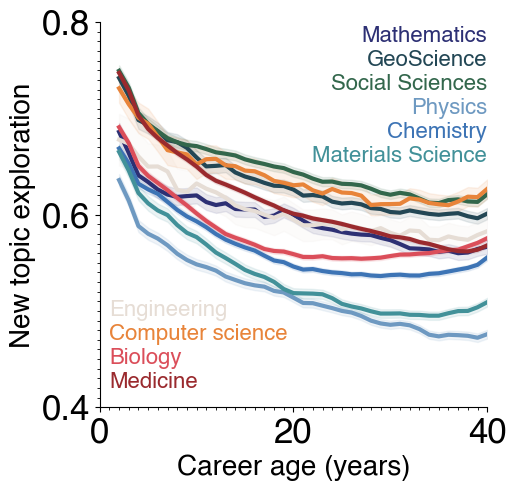

In [5]:
def np_move_avg(a,n,mode="valid"):
    return(np.convolve(a, np.ones((n,))/n, mode=mode))

plt.figure(figsize=(5,5))

file='./FigureData/Fig_E2.pkl'
tmp = fun_load_pickle(file)
k=0
window_size=2
for field in FieldList:
    x=range(2,41)
    y=tmp[field]
    y[:,0]=1-y[:,0]
    line_kws={'lw':2.5}
    y1,y2 = y[:,0]-y[:,1],y[:,0]+y[:,1]
    y1,y2 = np_move_avg(np.append(y1[:window_size-1],y1),window_size),np_move_avg(np.append(y2[:window_size-1],y2),window_size)
    plt.fill_between(np.array(x),y1,y2,color=color[k],alpha=.1)
    y0= np_move_avg(np.append(y[:window_size-1,0],y[:,0]),window_size)
    plt.plot(x,y0,color=color[k],lw=linewidth,label=field) 
    if k<=5:
        plt.text(40,.78-k/40,NameList[k],fontsize=16,color =color[k],ha='right') 
    else:
        plt.text(1,.52-(k-5)/40,NameList[k],fontsize=16,color =color[k],ha='left') 
    k+=1
    
#plt.legend()  
plt.ylim(0.4,0.8)
plt.xlim(0,40)
ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
ax.set_xticks([0,20,40])
ax.set_yticks([0.4,.6,.8])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Career age (years)',fontsize=label_fontsize)
plt.ylabel('New topic exploration',fontsize=label_fontsize)
plt.savefig('./fig/E2.pdf',bbox_inches='tight')